In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device : {device}")

Using Device : cuda


In [ ]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

In [ ]:
df['label'].value_counts()

,count
label,
2,6000
9,6000
6,6000
0,6000
3,6000
4,6000
5,6000
8,6000
7,6000


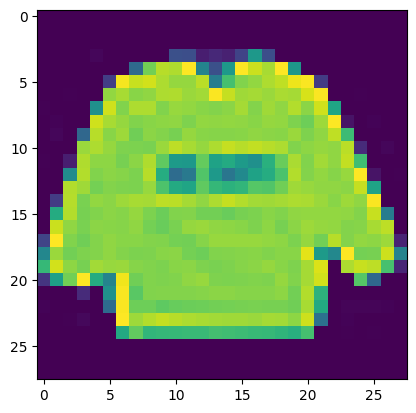

In [ ]:
img = df.iloc[0,1:].values.reshape(28,28)
plt.imshow(img)

In [ ]:
x = df.drop(columns = ['label']).values
y = df['label'].values

In [ ]:
x.shape

(60000, 784)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
#custom dataset class
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype = torch.float32)
    self.labels = torch.tensor(labels,dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]

In [ ]:
train_dataset = CustomDataset(x_train,y_train)
test_dataset = CustomDataset(x_test,y_test)

In [ ]:
train_dataset.features.shape
train_dataset.labels.shape

torch.Size([48000])

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True,pin_memory = True)
test_loader = DataLoader(test_dataset,batch_size = 32,shuffle = False,pin_memory = True)

In [ ]:
# Define NN class
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
# learning rate and epochs
learning_rate = 0.1
epochs = 100

In [ ]:
# create an object of your model
model = MyNN(x_train.shape[1])

# moving model to gpu
model = model.to(device)

#loss function
lossFN = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(),lr = learning_rate)

In [ ]:
#training loop

for epoch in range(epochs):
  # Load dataset in batches using dataloader
  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:

    # moving data to gpu
    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

    #forward pass
    output =  model(batch_features)

    #calculate loss
    loss = lossFN(output,batch_labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()

    #update gradients
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader)

  print(f"Epoch {epoch+1} , Loss : {avg_loss}")





Epoch 1 , Loss : 0.6352872474888961
Epoch 2 , Loss : 0.4304986953884363
Epoch 3 , Loss : 0.3861262078657746
Epoch 4 , Loss : 0.3584607255011797
Epoch 5 , Loss : 0.3376494748592377
Epoch 6 , Loss : 0.32276468626906474
Epoch 7 , Loss : 0.3078539018382629
Epoch 8 , Loss : 0.2949818898836772
Epoch 9 , Loss : 0.2854692505300045
Epoch 10 , Loss : 0.27467058210571604
Epoch 11 , Loss : 0.26830569267148774
Epoch 12 , Loss : 0.2581421597401301
Epoch 13 , Loss : 0.24940819991752505
Epoch 14 , Loss : 0.24444738873218497
Epoch 15 , Loss : 0.2385919222868979
Epoch 16 , Loss : 0.23155899402375021
Epoch 17 , Loss : 0.22562562982489665
Epoch 18 , Loss : 0.2202964697740972
Epoch 19 , Loss : 0.21206334652379155
Epoch 20 , Loss : 0.20960091769819458
Epoch 21 , Loss : 0.20624992956593632
Epoch 22 , Loss : 0.19986103242821993
Epoch 23 , Loss : 0.1953041393881043
Epoch 24 , Loss : 0.19312163671137145
Epoch 25 , Loss : 0.18764107141271233
Epoch 26 , Loss : 0.18366442496639987
Epoch 27 , Loss : 0.1801829954385

In [ ]:
#evaluation mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
#evaluation code
total = 0
correct = 0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:

    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
    #forward pass
    output = model(batch_features)

    _,predicted = torch.max(output,1)

    total += batch_labels.shape[0]

    correct += (predicted == batch_labels).sum().item()

print(f"Accuracy : {correct/total}")

Accuracy : 0.8898333333333334
